In [ ]:
from google.colab import drive
import os

if not os.path.ismount('/content/drive'):
    # Clear any existing content at the mount point (use with caution!)
    !rm -rf /content/drive
    drive.mount('/content/drive')
else:
    print("✅ Google Drive is already mounted!")

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB6
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math
import matplotlib.pyplot as plt

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (528, 528)  # EfficientNetB6 input size
BATCH_SIZE = 4         # Very memory heavy, keep low
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Generators ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load EfficientNetB6 Base ---
base_model = EfficientNetB6(weights='imagenet', include_top=False, input_shape=(528, 528, 3))
base_model.trainable = False  # freeze base for phase 1

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(len(CLASS_NAMES), activation='softmax')
])

# --- Compile for Phase 1 ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, verbose=1)

# --- Phase 1: Train Top Layers ---
print("\n🔧 Training top layers...\n")
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Phase 2: Fine-tune Full Model ---
print("\n🧠 Fine-tuning full model...\n")
base_model.trainable = True
for layer in base_model.layers[:-10]:  # leave last few frozen
    layer.trainable = True

# Cosine Annealing LR
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / EPOCHS_TOTAL)) / 2

lr_scheduler = LearningRateScheduler(cosine_annealing)

model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# --- Train Full Model ---
history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# --- Evaluate on Test Set ---
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\n📊 Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"🧪 Test Loss: {test_loss:.4f}")

# --- Save Model ---
model.save("efficientnetB6_brain_tumor.keras")

Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
165234480/165234480 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

🔧 Training top layers...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 1989s 2s/step - accuracy: 0.4954 - loss: 3.6284 - val_accuracy: 0.8359 - val_loss: 2.7409 - learning_rate: 1.0000e-04
Epoch 2/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 352s 381ms/step - accuracy: 0.6518 - loss: 3.1281 - val_accuracy: 0.8725 - val_loss: 2.6624 - learning_rate: 1.0000e-04
Epoch 3/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 350s 379ms/step - accuracy: 0.7129 - loss: 2.9498 - val_accuracy: 0.8699 - val_loss: 2.6190 - learning_rate: 1.0000e-04
Epoch 4/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 356s 386ms/step - accuracy: 0.7149 - loss: 2.8464 - val_accuracy: 0.8687 - val_loss: 2.5667 - learning_rate: 1.0000e-04
Epoch 5/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 352s 380ms/step - accuracy: 0.7439 - loss: 2.7448 - val_accuracy: 0.8763 - val_loss: 2.4904 - learning_rate: 1.0000e-04
Epoch 6/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 375s 406ms/step - accuracy: 0.7329 - loss: 2.6746 - val_accuracy: 0.8725 - val_loss: 2.4205 - learning_rate: 1.0000e-04
Epoch 7/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 36

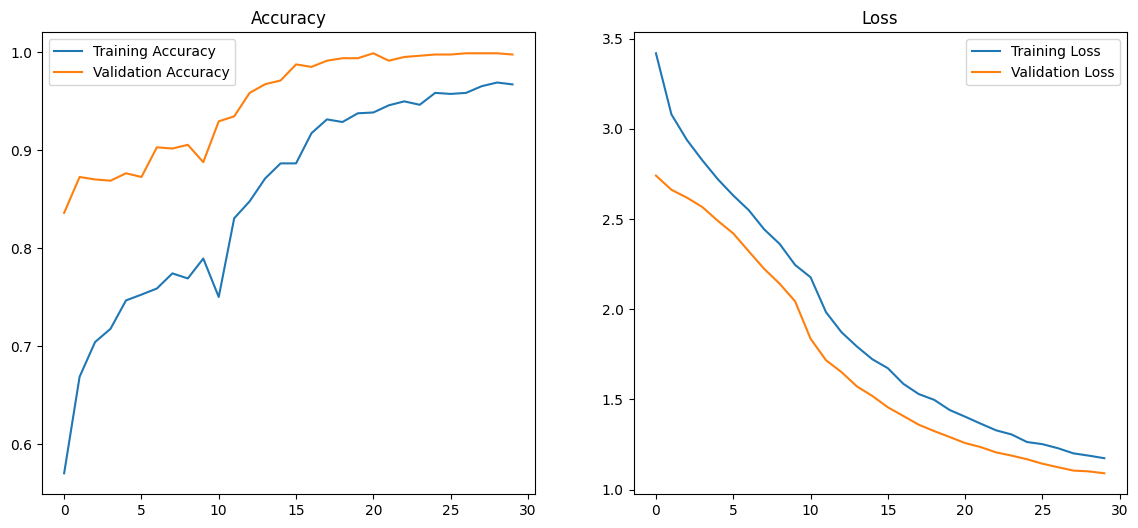

In [ ]:
# --- Plot Training History ---
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

def plot_training_history(history):
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Loss')

    plt.show()

combined_history = combine_histories(history1, history2)
plot_training_history(combined_history)

In [ ]:
from sklearn.metrics import classification_report

y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_labels = list(test_generator.class_indices.keys())

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

198/198 ━━━━━━━━━━━━━━━━━━━━ 42s 144ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.98      0.98       198
  meningioma       0.97      0.97      0.97       198
     notumor       1.00      1.00      1.00       198
   pituitary       0.98      0.99      0.99       198

    accuracy                           0.99       792
   macro avg       0.99      0.99      0.99       792
weighted avg       0.99      0.99      0.99       792



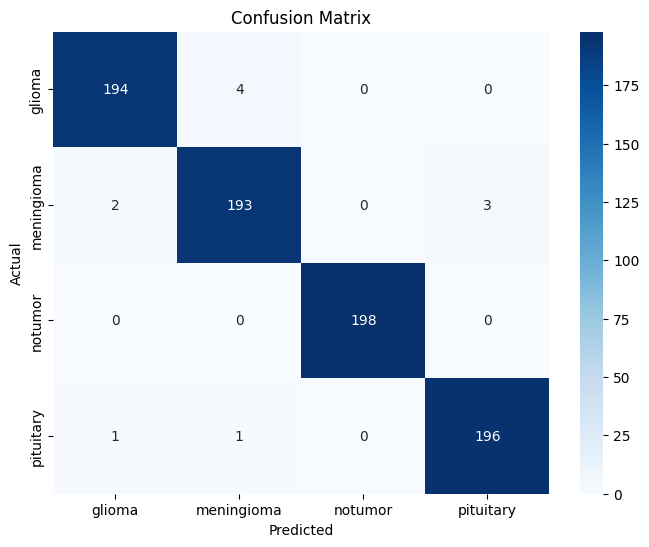

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

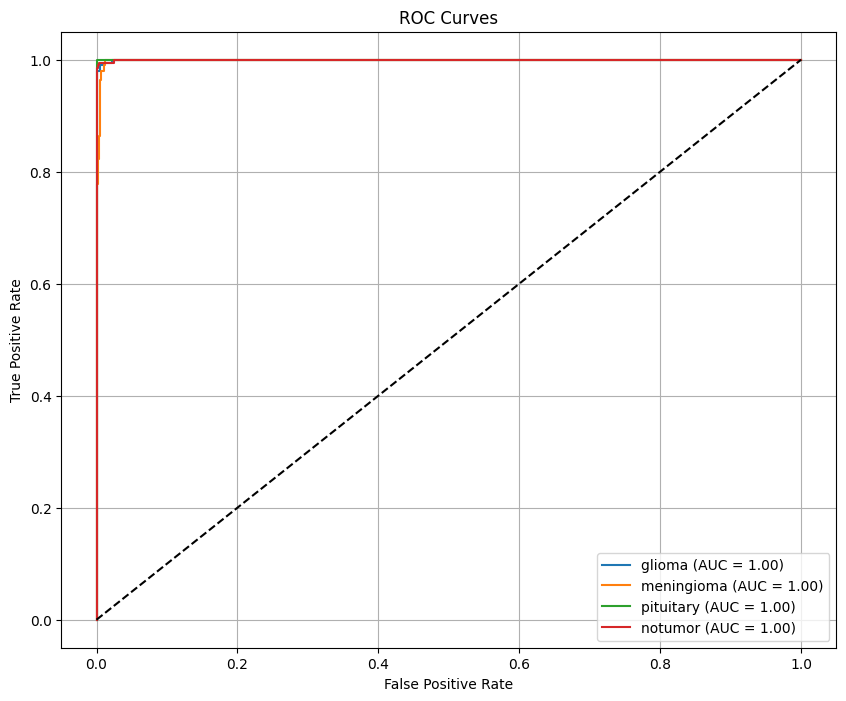

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize labels
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(CLASS_NAMES)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(CLASS_NAMES)):
    plt.plot(fpr[i], tpr[i], label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid()
plt.show()

/tmp/ipython-input-9-3641419992.py:20: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


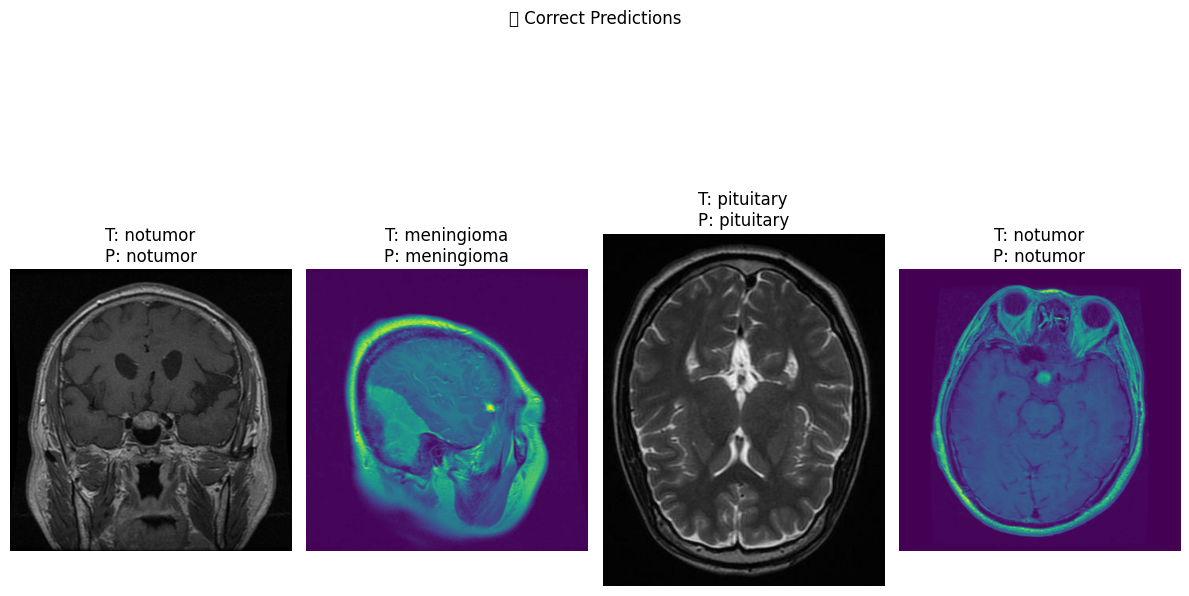

/tmp/ipython-input-9-3641419992.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


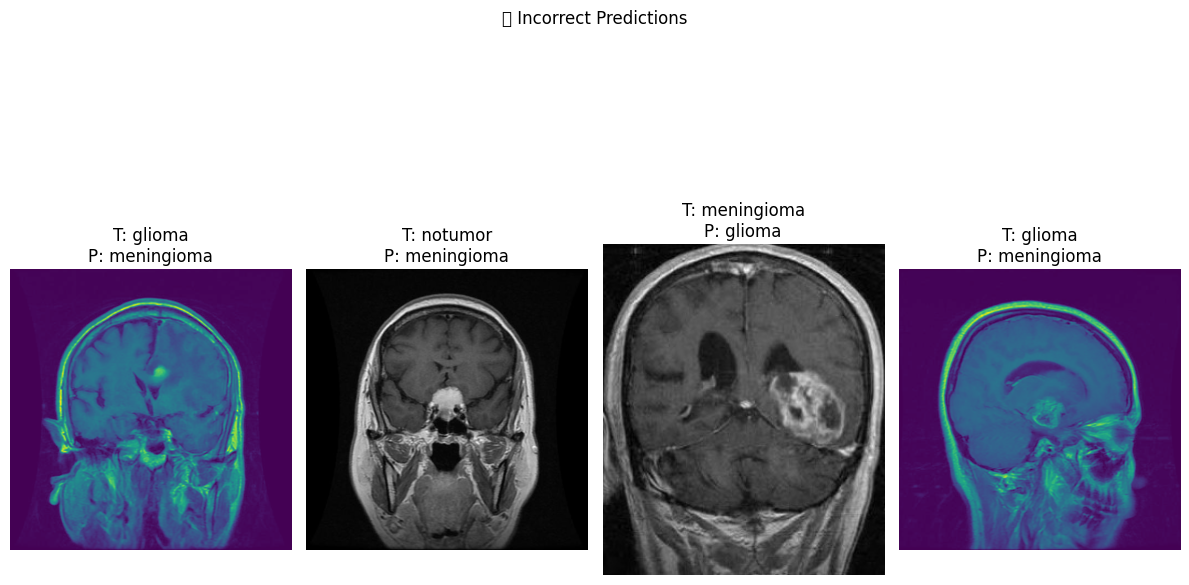

In [ ]:
import random

# Get filenames and true/pred labels
file_paths = test_generator.filepaths
correct_indices = np.where(y_true == y_pred)[0]
wrong_indices = np.where(y_true != y_pred)[0]

def plot_sample_predictions(indices, title, n=4):
    plt.figure(figsize=(12, 8))
    selected = random.sample(list(indices), min(n, len(indices)))
    for i, idx in enumerate(selected):
        img = plt.imread(file_paths[idx])
        true_label = CLASS_NAMES[y_true[idx]]
        pred_label = CLASS_NAMES[y_pred[idx]]
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot correct predictions
plot_sample_predictions(correct_indices, "✅ Correct Predictions", n=4)

# Plot incorrect predictions
plot_sample_predictions(wrong_indices, "❌ Incorrect Predictions", n=4)

In [ ]:
import os

root = "/content/drive/MyDrive/BalancedBrainTumorDataset"
print("Folders inside Training:")
print(os.listdir(root + "/Training"))


Folders inside Training:


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BalancedBrainTumorDataset/Training'

In [ ]:
import os
print("BalancedBrainTumorDataset:")
print(os.listdir("/content/drive/MyDrive/BalancedBrainTumorDataset"))


BalancedBrainTumorDataset:
['train', 'val', 'test']


In [ ]:
import os

root = "/content/drive/MyDrive/BalancedBrainTumorDataset"

for split in ["train", "val", "test"]:
    print(f"\nFolders inside {split}:")
    print(os.listdir(os.path.join(root, split)))



Folders inside train:
['glioma', 'meningioma', 'pituitary', 'notumor']

Folders inside val:
['glioma', 'meningioma', 'pituitary', 'notumor']

Folders inside test:
['glioma', 'meningioma', 'pituitary', 'notumor']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB6
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import os, math
import pandas as pd

# -------------------------
# CONFIG
# -------------------------
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (528, 528)
BATCH_SIZE = 4
NUM_CLASSES = 4
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 20
FOLDS = 5

# -------------------------
# LOAD ALL FILE PATHS + LABELS
# -------------------------
def load_dataset_paths(split):
    base = os.path.join(DATASET_PATH, split)
    filepaths = []
    labels = []

    for label, cls in enumerate(CLASS_NAMES):
        cls_path = os.path.join(base, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(("jpg", "png", "jpeg")):
                filepaths.append(os.path.join(cls_path, f))
                labels.append(label)
    return np.array(filepaths), np.array(labels)


X_paths, y_labels = load_dataset_paths("train")
print("Total Training Images:", len(X_paths))

# -------------------------
# DATA GENERATORS
# -------------------------
train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

test_aug = ImageDataGenerator(preprocessing_function=preprocess_input)

# -------------------------
# FIXED LABEL HANDLING (IMPORTANT)
# -------------------------
def build_flow(paths, labels, aug=False):
    datagen = train_aug if aug else test_aug

    # Convert numeric labels → class names
    str_labels = np.array(CLASS_NAMES)[labels]

    df = pd.DataFrame({"filename": paths, "class": str_labels})

    gen = datagen.flow_from_dataframe(
        dataframe=df,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        shuffle=aug
    )
    return gen

# -------------------------
# MODEL
# -------------------------
def build_model():
    base = EfficientNetB6(weights="imagenet", include_top=False, input_shape=(528, 528, 3))
    base.trainable = False

    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(1024, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.6),
        Dense(512, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation="softmax")
    ])
    return model

# -------------------------
# COSINE ANNEALING LR
# -------------------------
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / total_epochs)) / 2

# -------------------------
# CROSS-VALIDATION
# -------------------------
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_paths, y_labels), 1):

    print(f"\n========== FOLD {fold}/{FOLDS} ==========")

    train_x, val_x = X_paths[train_idx], X_paths[val_idx]
    train_y, val_y = y_labels[train_idx], y_labels[val_idx]

    train_gen = build_flow(train_x, train_y, aug=True)
    val_gen = build_flow(val_x, val_y, aug=False)

    model = build_model()

    # --- PHASE 1 ---
    model.compile(
        optimizer=Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )

    early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2)

    print("\n🔧 Phase 1 Training...\n")
    model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_PHASE1,
              callbacks=[early, reduce], verbose=1)

    # --- PHASE 2 ---
    model.layers[0].trainable = True

    model.compile(
        optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"]
    )

    lr_sched = LearningRateScheduler(cosine_annealing)

    print("\n🧠 Fine-Tuning Phase 2...\n")
    model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_PHASE2,
              callbacks=[early, reduce, lr_sched], verbose=1)

    # --- EVALUATE ---
    val_gen.reset()
    preds = model.predict(val_gen)
    y_pred = np.argmax(preds, axis=1)

    acc = accuracy_score(val_y, y_pred)
    prec = precision_score(val_y, y_pred, average='macro')
    rec = recall_score(val_y, y_pred, average='macro')
    f1 = f1_score(val_y, y_pred, average='macro')
    auc = roc_auc_score(to_categorical(val_y), preds, multi_class='ovr')

    results.append([acc, prec, rec, f1, auc])

    print(f"\nFOLD {fold} RESULTS:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

# -------------------------
# FINAL SUMMARY
# -------------------------
results = np.array(results)
mean = results.mean(axis=0)
std = results.std(axis=0)

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]

print("\n========== FINAL 5-FOLD CROSS-VALIDATION SUMMARY ==========\n")
for i, m in enumerate(metrics):
    print(f"{m}: {mean[i]:.4f} ± {std[i]:.4f}")


Total Training Images: 3696

========== FOLD 1/5 ==========
Found 2956 validated image filenames belonging to 4 classes.
Found 740 validated image filenames belonging to 4 classes.
165234480/165234480 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

🔧 Phase 1 Training...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 2359s 3s/step - accuracy: 0.4889 - loss: 3.6943 - val_accuracy: 0.8230 - val_loss: 2.8134 - learning_rate: 1.0000e-04
Epoch 2/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 292s 396ms/step - accuracy: 0.6399 - loss: 3.1944 - val_accuracy: 0.8419 - val_loss: 2.7476 - learning_rate: 1.0000e-04
Epoch 3/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 294s 398ms/step - accuracy: 0.6913 - loss: 3.0189 - val_accuracy: 0.8581 - val_loss: 2.6748 - learning_rate: 1.0000e-04
Epoch 4/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 293s 397ms/step - accuracy: 0.6893 - loss: 2.9483 - val_accuracy: 0.8581 - val_loss: 2.6281 - learning_rate: 1.0000e-04
Epoch 5/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 297s 401ms/step - accuracy: 0.7359 - loss: 2.8002 - val_accuracy: 0.8703 - val_loss: 2.5712 - learning_rate: 1.0000e-04
Epoch 6/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 289s 391ms/step - accuracy: 0.7439 - loss: 2.7516 - val_accuracy: 0.8649 - val_loss: 2.5697 - learning_rate: 1.0000e-04
Epoch 7/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 29

KeyboardInterrupt: 